# 04 · EDA – Análisis multivariado, hipótesis e insights
**Responsable:** Duban
**Objetivo:** estudiar cómo se relacionan las variables entre sí y con la variable objetivo: correlaciones, tablas cruzadas, fuerza de asociación entre categóricas (V de Cramer) y prueba formal de 5 hipótesis sobre qué hace que un cliente suscriba el depósito.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # para poder importar src/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import (configurar_graficos, cargar_datos, guardar_figura,
                       VARIABLES_NUMERICAS, VARIABLES_CATEGORICAS, OBJETIVO,
                       RUTA_PROCESADOS)
configurar_graficos()
from scipy import stats
df = pd.read_csv(RUTA_PROCESADOS / "bank_limpio.csv")
print(df.shape)
df.head()

(41176, 22)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,contactado_antes
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0
1,53,technician,married,university.degree,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1,1


## 1. Correlaciones entre variables numéricas
Se calculan dos coeficientes:
- **Pearson:** mide relación *lineal*.
- **Spearman:** usa rangos, por lo que es más adecuado aquí, ya que ninguna variable es normal (ver notebook 03).

`pdays` se excluye porque el 96 % de sus valores es 999 (ya está resumida en `contactado_antes`).

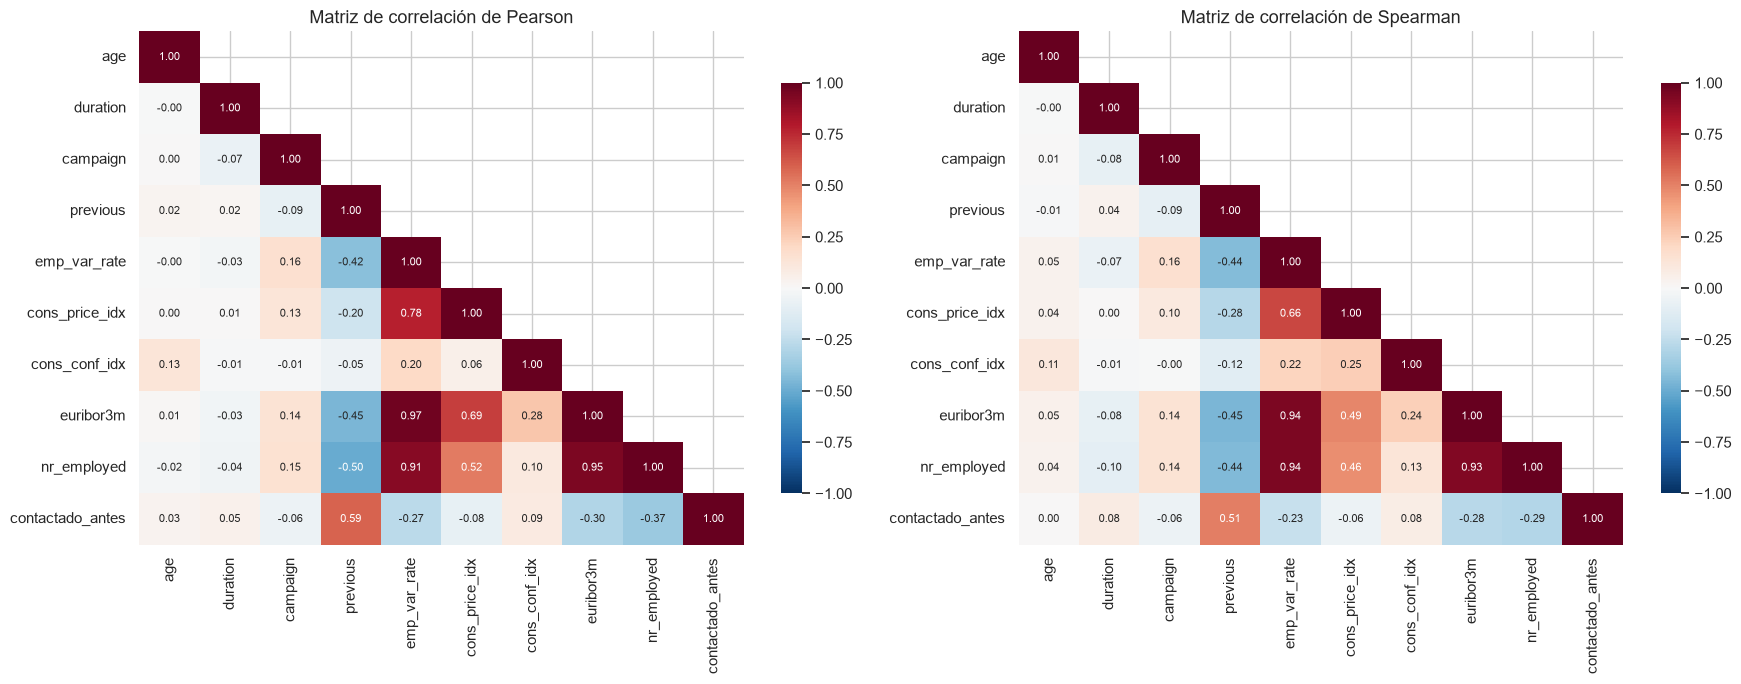

In [2]:
num = [c for c in VARIABLES_NUMERICAS if c != "pdays"] + ["contactado_antes"]
corr_pearson = df[num].corr(method="pearson")
corr_spearman = df[num].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, matriz, nombre in zip(axes, [corr_pearson, corr_spearman], ["Pearson", "Spearman"]):
    mascara = np.triu(np.ones_like(matriz, dtype=bool), k=1)
    sns.heatmap(matriz, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
                ax=ax, cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
    ax.set_title(f"Matriz de correlación de {nombre}")
plt.tight_layout()
guardar_figura("04_mapa_calor_correlaciones")
plt.show()

In [3]:
# Pares de variables con correlación fuerte (|r| > 0,7) -> riesgo de multicolinealidad
pares = (corr_spearman.where(np.triu(np.ones_like(corr_spearman, dtype=bool), k=1))
         .stack().rename("spearman").to_frame())
pares["pearson"] = corr_pearson.where(np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)).stack()
pares = pares[pares["spearman"].abs() > 0.7].sort_values("spearman", key=abs, ascending=False)
pares.round(3)

spearman  pearson
emp_var_rate nr_employed     0.945    0.907
             euribor3m       0.940    0.972
euribor3m    nr_employed     0.929    0.945

### Correlación de cada variable numérica con la variable objetivo
Como `y` es binaria, la correlación de Pearson con `y` equivale a la **correlación punto-biserial**.

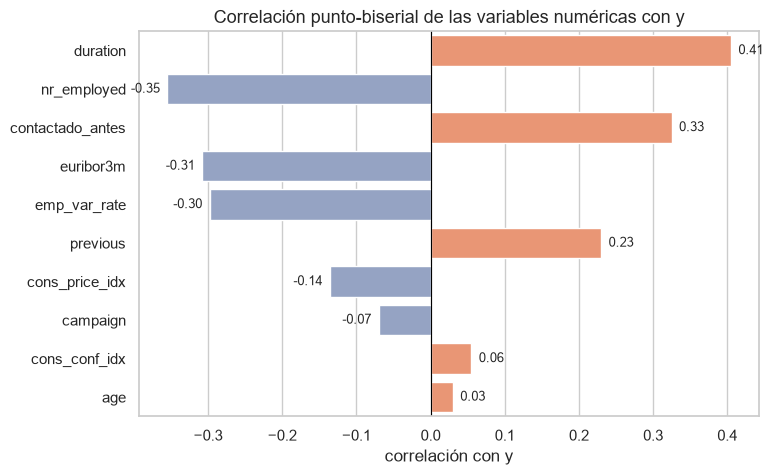

,r_punto_biserial,rho_spearman,p_valor
variable,,,
duration,0.405,0.349,0.000000e+00
nr_employed,-0.355,-0.284,0.000000e+00
contactado_antes,0.325,0.325,0.000000e+00
euribor3m,-0.308,-0.267,0.000000e+00
emp_var_rate,-0.298,-0.247,0.000000e+00
previous,0.230,0.201,0.000000e+00
cons_price_idx,-0.136,-0.122,1.622233e-169
campaign,-0.070,-0.064,3.948046e-46
cons_conf_idx,0.055,0.041,9.132176e-29


In [4]:
filas = []
for col in num:
    r, p = stats.pointbiserialr(df[OBJETIVO], df[col])
    rho, _ = stats.spearmanr(df[OBJETIVO], df[col])
    filas.append([col, round(r, 3), round(rho, 3), p])
corr_y = (pd.DataFrame(filas, columns=["variable", "r_punto_biserial", "rho_spearman", "p_valor"])
          .set_index("variable").sort_values("r_punto_biserial", key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
colores = ["#fc8d62" if v > 0 else "#8da0cb" for v in corr_y["r_punto_biserial"]]
sns.barplot(x=corr_y["r_punto_biserial"], y=corr_y.index, palette=colores, ax=ax)
for i, v in enumerate(corr_y["r_punto_biserial"]):
    ax.text(v + (0.01 if v > 0 else -0.01), i, f"{v:.2f}", va="center", ha="left" if v > 0 else "right", fontsize=9)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("correlación con y"); ax.set_ylabel("")
ax.set_title("Correlación punto-biserial de las variables numéricas con y")
guardar_figura("04_correlacion_con_objetivo")
plt.show()
corr_y

## 2. Relaciones entre pares de variables (pairplot)
Se toma una muestra de 3.000 clientes para que el gráfico sea legible, coloreando por la variable objetivo.

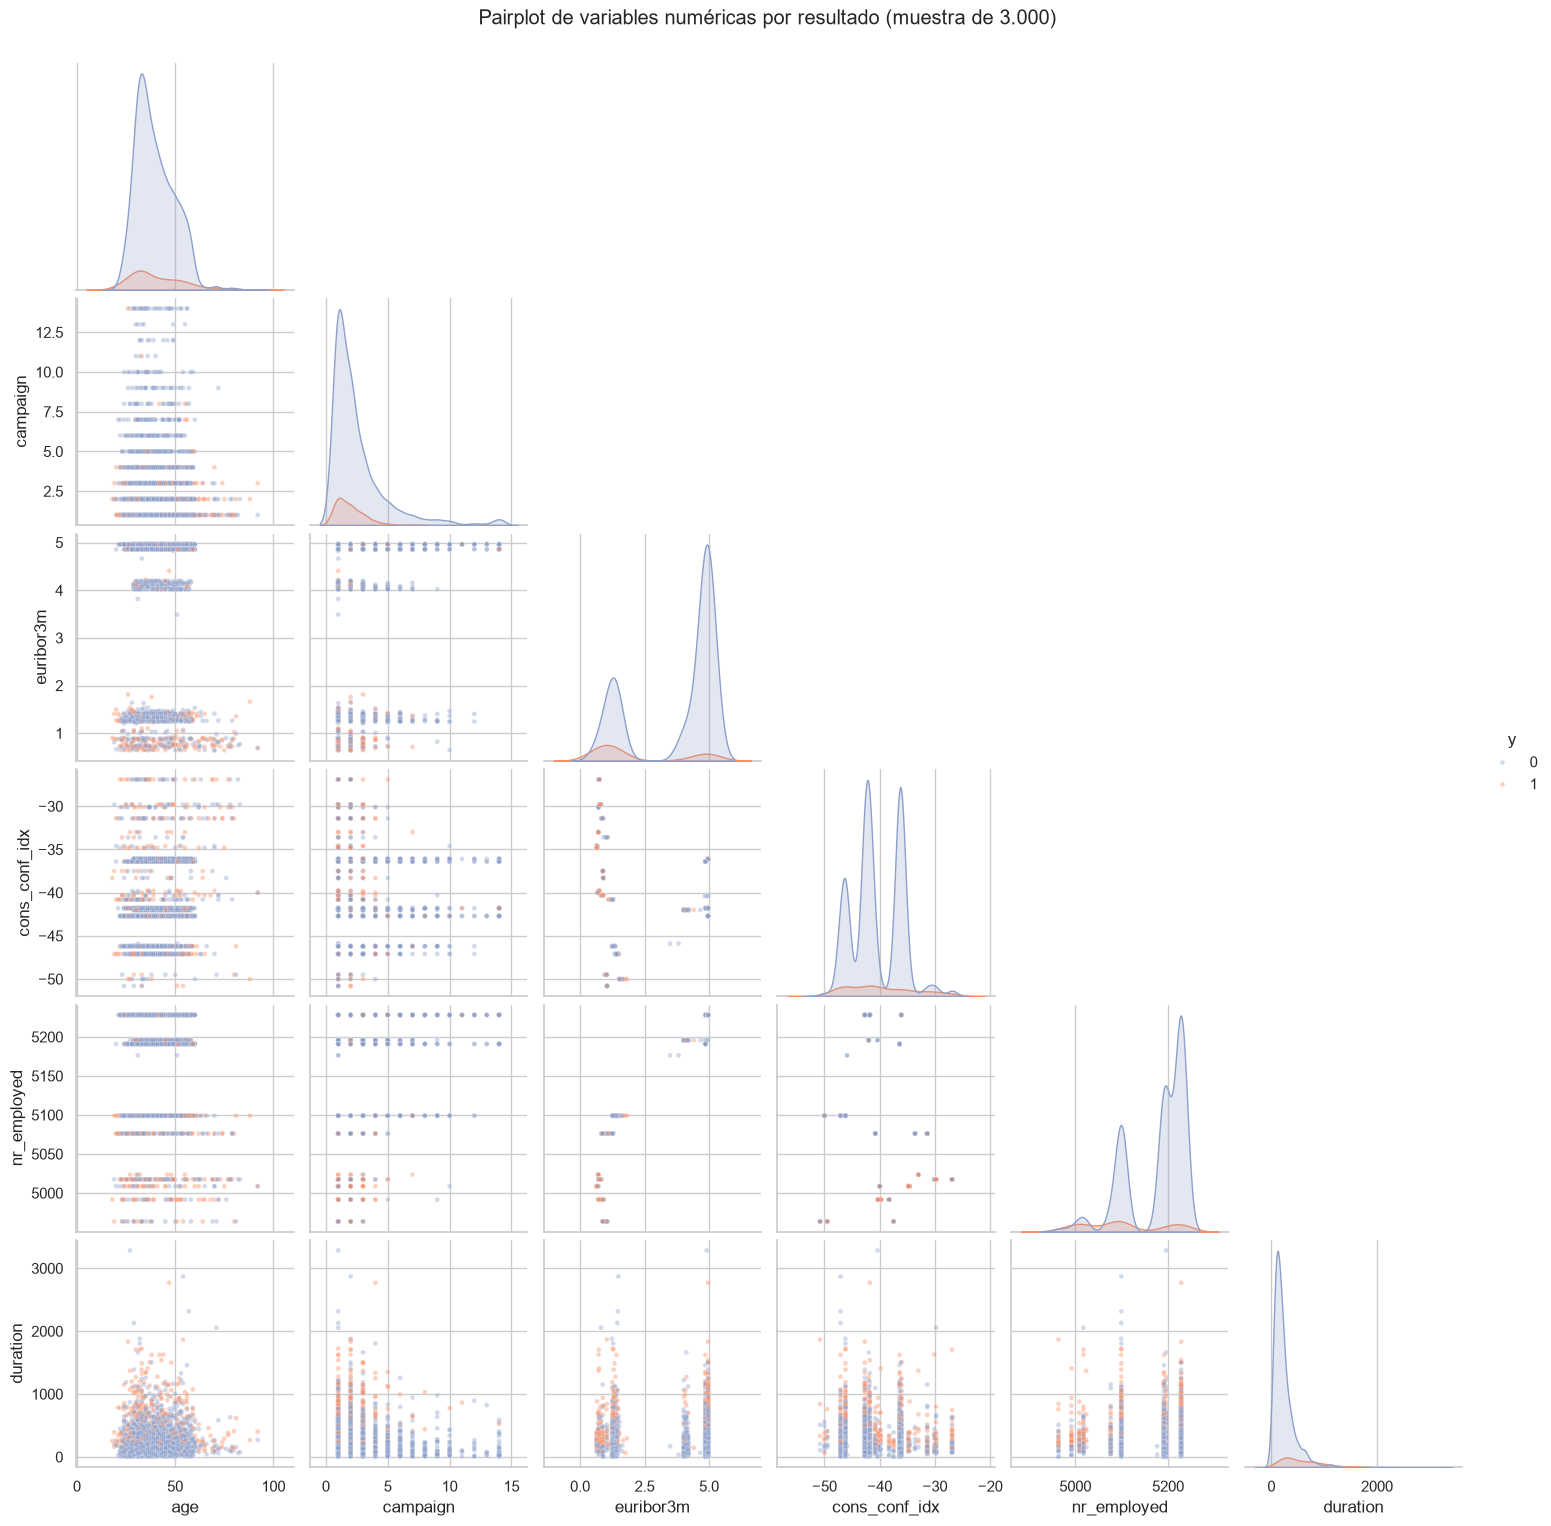

In [5]:
vars_pair = ["age", "campaign", "euribor3m", "cons_conf_idx", "nr_employed", "duration"]
muestra = df.sample(3000, random_state=42)
g = sns.pairplot(muestra, vars=vars_pair, hue=OBJETIVO, palette={0: "#8da0cb", 1: "#fc8d62"},
                 plot_kws={"alpha": 0.4, "s": 12}, diag_kind="kde", corner=True)
g.fig.suptitle("Pairplot de variables numéricas por resultado (muestra de 3.000)", y=1.02)
guardar_figura("04_pairplot")
plt.show()

In [6]:
# Comparación de medianas entre quienes suscribieron y quienes no
comparacion = df.groupby(OBJETIVO)[vars_pair].median().T
comparacion.columns = ["mediana_no", "mediana_si"]
comparacion["diferencia"] = comparacion["mediana_si"] - comparacion["mediana_no"]
comparacion.round(2)

,mediana_no,mediana_si,diferencia
age,38.00,37.00,-1.00
campaign,2.00,2.00,0.00
euribor3m,4.86,1.27,-3.59
cons_conf_idx,-41.80,-40.40,1.40
nr_employed,5195.80,5099.10,-96.70
duration,164.00,449.00,285.00


## 3. Tablas cruzadas: variables categóricas vs. objetivo
Para cada categoría se calcula la **tasa de suscripción** (% de `y = 1`). La línea punteada es la tasa global (≈11,3 %).

In [7]:
tasa_global = df[OBJETIVO].mean() * 100
pd.crosstab(df["poutcome"], df[OBJETIVO], margins=True, margins_name="Total")

y,0,1,Total
poutcome,,,
failure,3647,605,4252
nonexistent,32411,3140,35551
success,479,894,1373
Total,36537,4639,41176


In [8]:
pd.crosstab(df["poutcome"], df[OBJETIVO], normalize="index").mul(100).round(1)

y,0,1
poutcome,,
failure,85.8,14.2
nonexistent,91.2,8.8
success,34.9,65.1


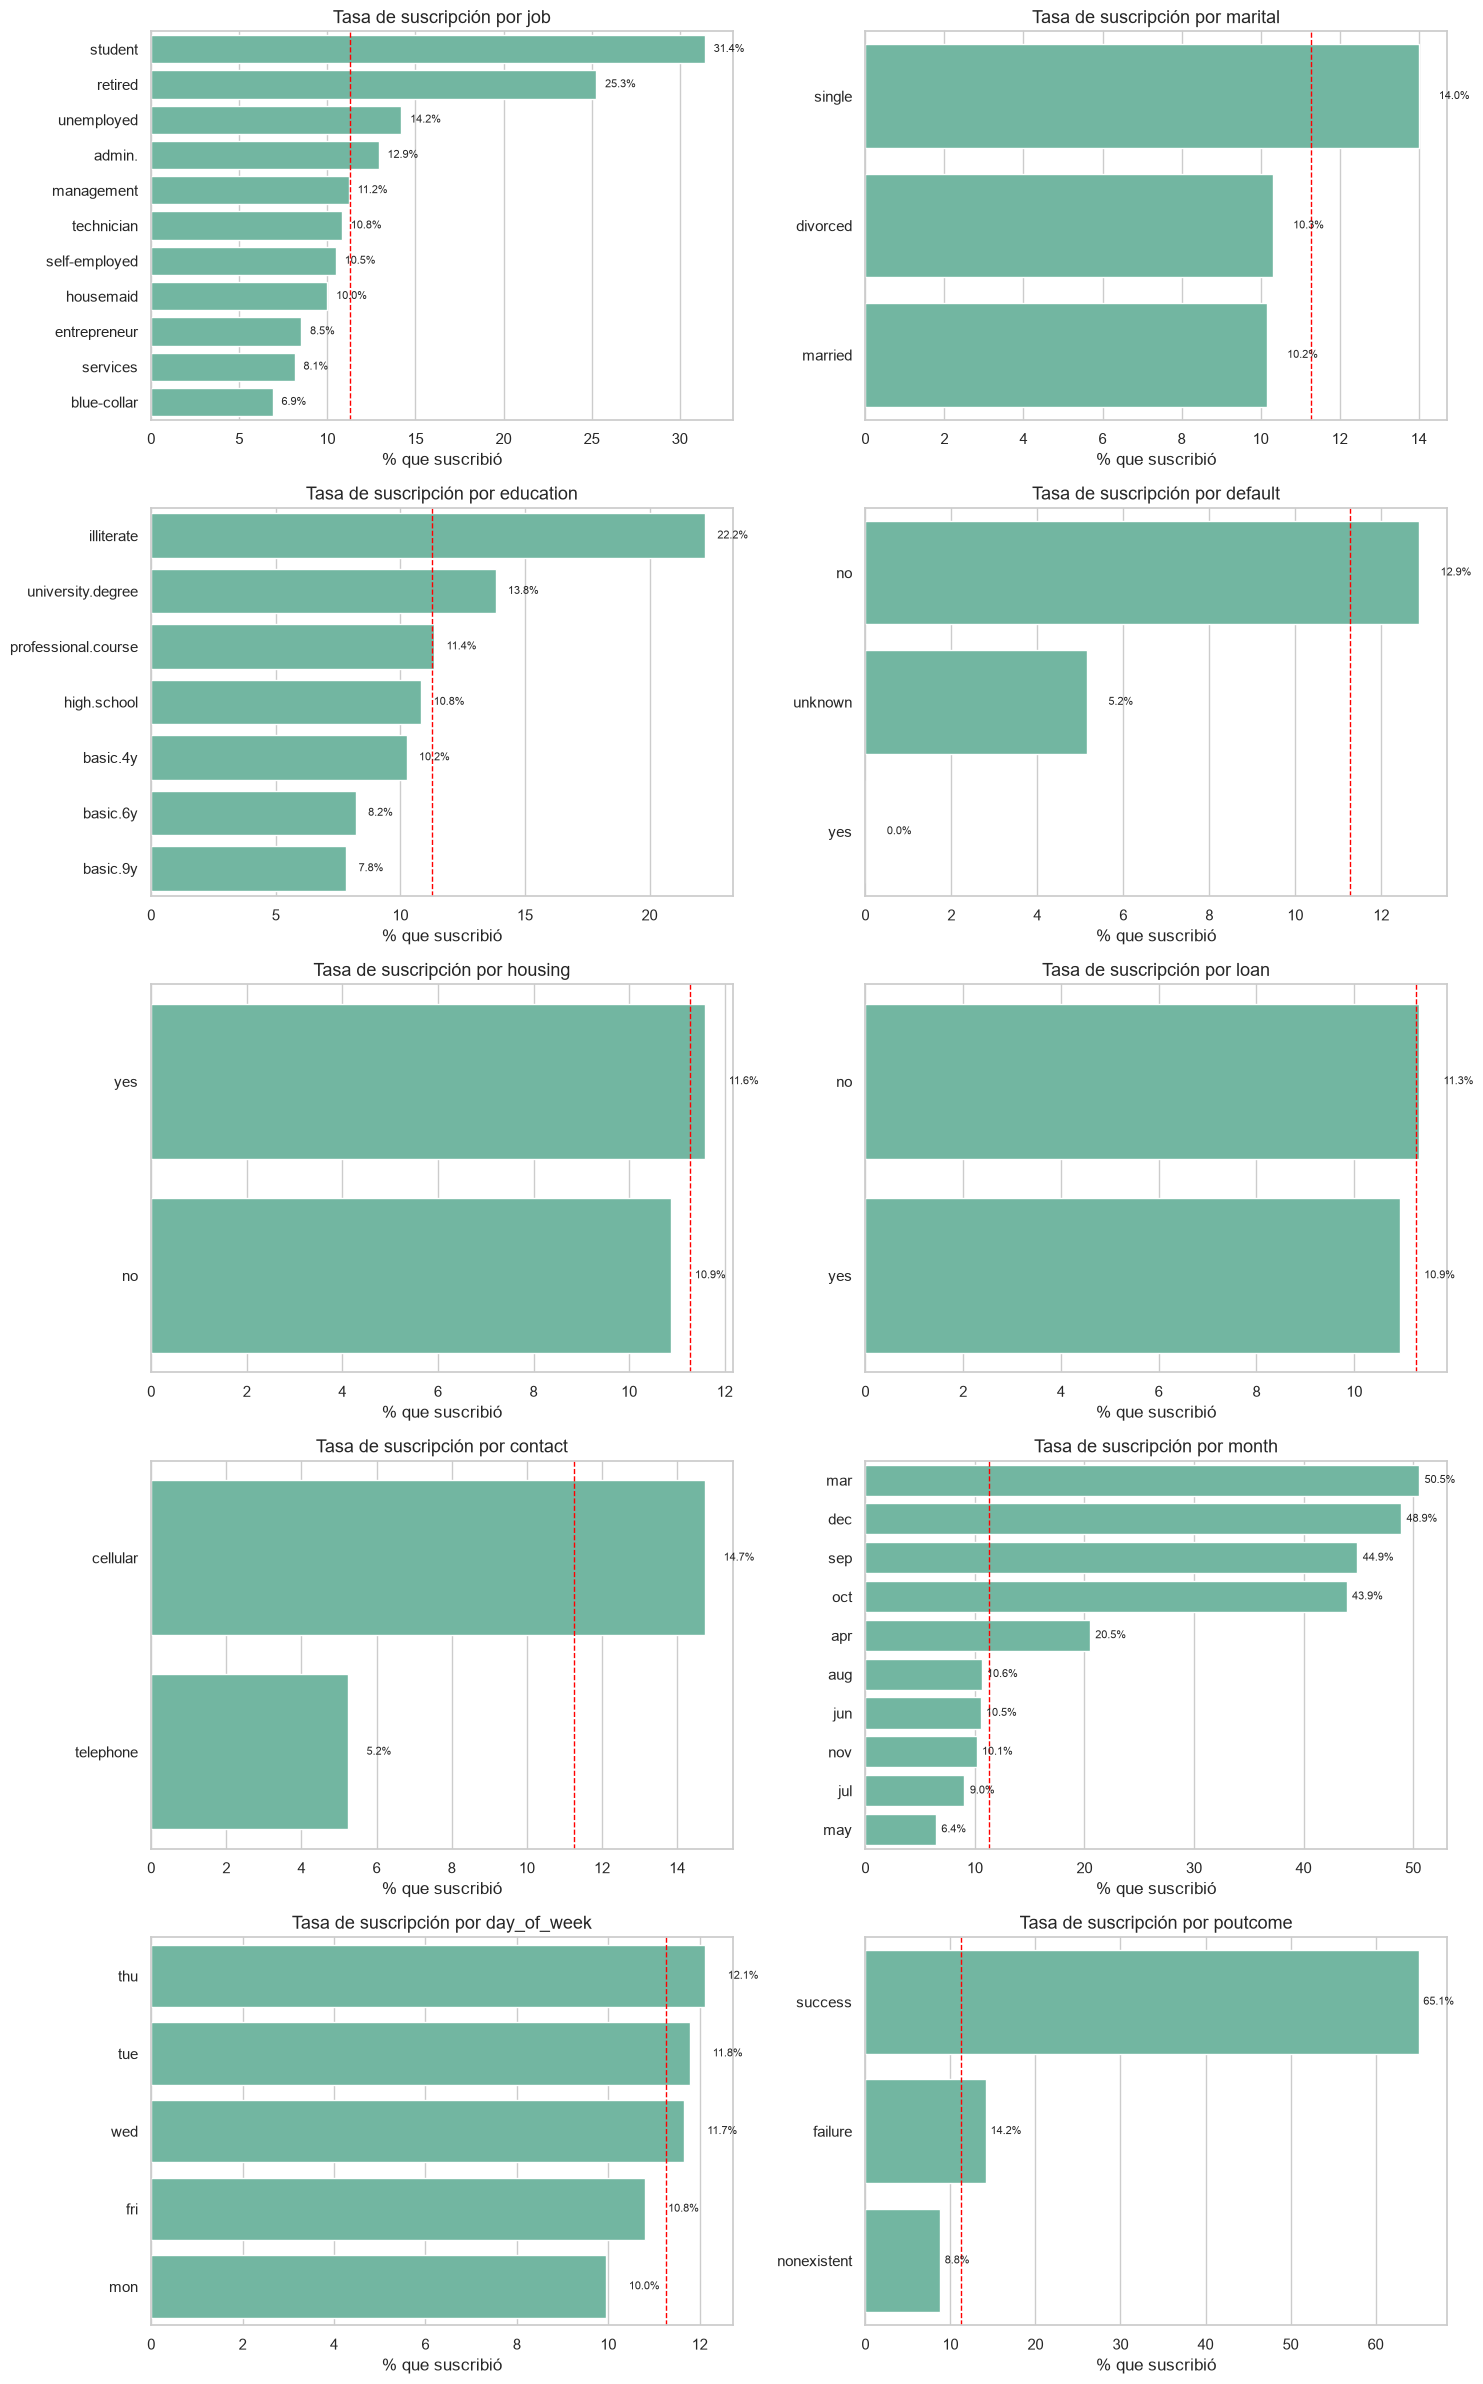

In [9]:
cats = VARIABLES_CATEGORICAS
fig, axes = plt.subplots(5, 2, figsize=(15, 24))
for col, ax in zip(cats, axes.flat):
    tasa = df.groupby(col)[OBJETIVO].mean().mul(100).sort_values(ascending=False)
    sns.barplot(x=tasa.values, y=tasa.index, ax=ax, color="#66c2a5")
    ax.axvline(tasa_global, color="red", ls="--", lw=1)
    for i, v in enumerate(tasa.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
    ax.set_title(f"Tasa de suscripción por {col}"); ax.set_xlabel("% que suscribió"); ax.set_ylabel("")
plt.tight_layout()
guardar_figura("04_tasa_suscripcion_por_categoria")
plt.show()

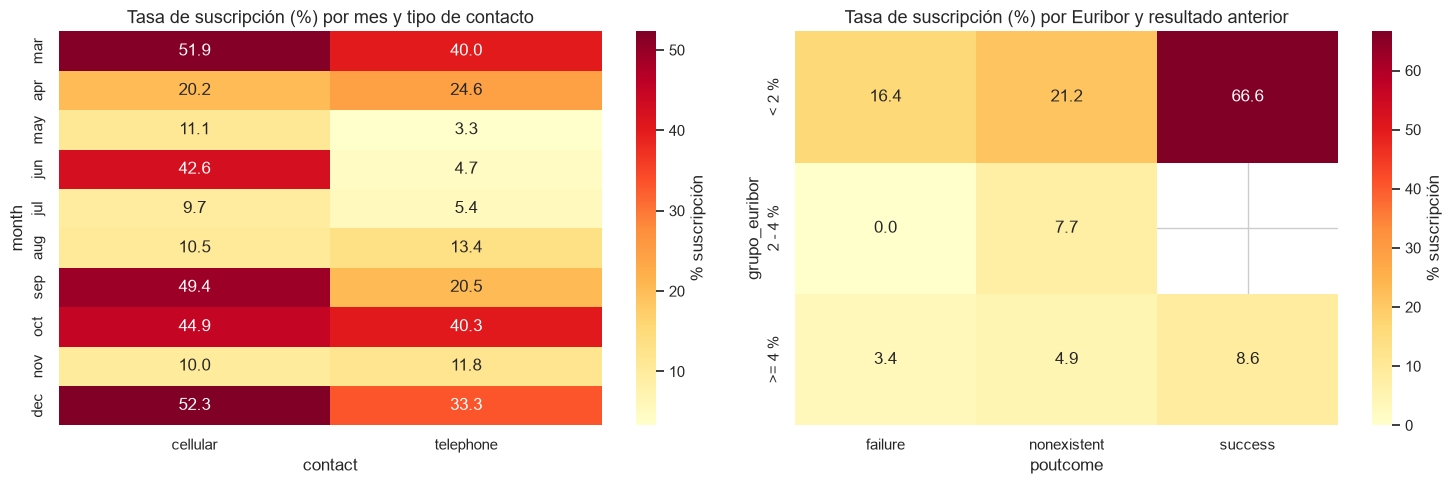

contact,cellular,telephone
month,,
mar,51.9,40.0
apr,20.2,24.6
may,11.1,3.3
jun,42.6,4.7
jul,9.7,5.4
aug,10.5,13.4
sep,49.4,20.5
oct,44.9,40.3
nov,10.0,11.8


In [10]:
# Tabla cruzada de dos variables a la vez: mes x tipo de contacto (tasa de suscripción, %)
orden_meses = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
tabla_mes_contacto = pd.crosstab(df["month"], df["contact"], values=df[OBJETIVO], aggfunc="mean").mul(100)
tabla_mes_contacto = tabla_mes_contacto.reindex(orden_meses).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(tabla_mes_contacto, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0], cbar_kws={"label": "% suscripción"})
axes[0].set_title("Tasa de suscripción (%) por mes y tipo de contacto")

df["grupo_euribor"] = pd.cut(df["euribor3m"], bins=[0, 2, 4, 6], labels=["< 2 %", "2 - 4 %", ">= 4 %"])
tabla_eur_pout = pd.crosstab(df["grupo_euribor"], df["poutcome"], values=df[OBJETIVO], aggfunc="mean").mul(100).round(1)
sns.heatmap(tabla_eur_pout, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "% suscripción"})
axes[1].set_title("Tasa de suscripción (%) por Euribor y resultado anterior")
plt.tight_layout()
guardar_figura("04_mapa_calor_tablas_cruzadas")
plt.show()
tabla_mes_contacto

## 4. Fuerza de asociación entre categóricas: V de Cramer
La correlación no sirve para variables categóricas. La **V de Cramer** se calcula a partir del estadístico chi-cuadrado y va de 0 (sin asociación) a 1 (asociación perfecta):

$$V = \sqrt{\frac{\chi^2}{n \cdot (\min(r, c) - 1)}}$$

Interpretación usada: < 0,1 débil · 0,1 – 0,3 moderada · > 0,3 fuerte.

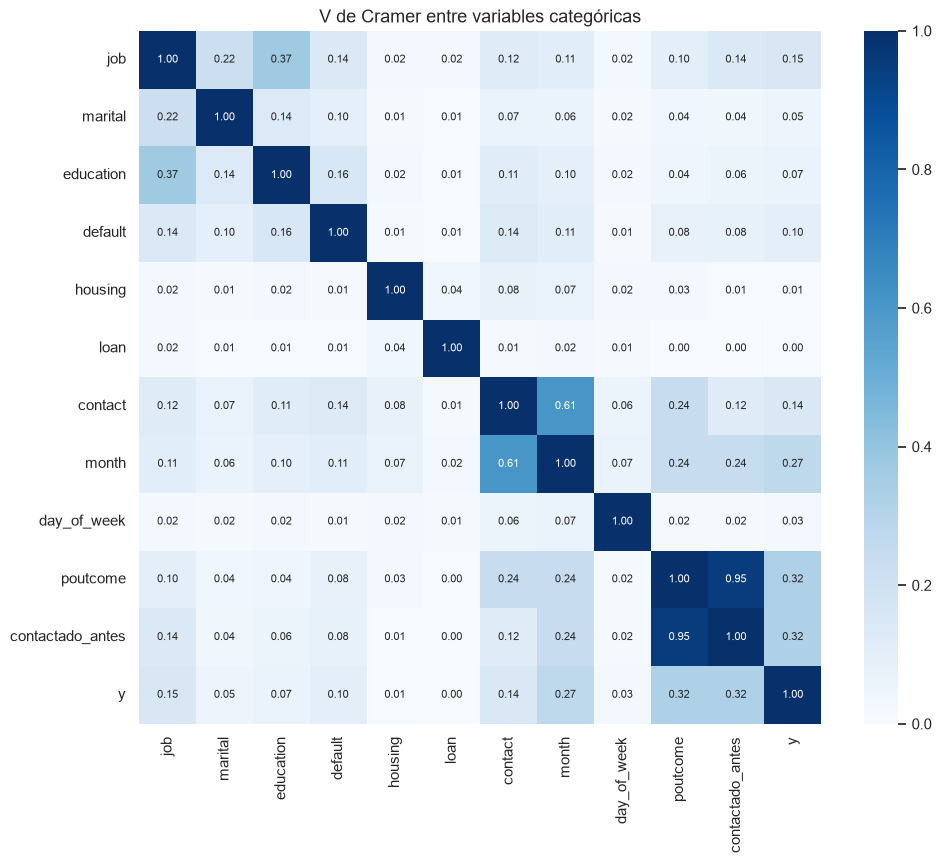

In [11]:
def v_cramer(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tabla, correction=False)[0]
    n = tabla.values.sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

vars_cramer = cats + ["contactado_antes", OBJETIVO]
matriz_v = pd.DataFrame(index=vars_cramer, columns=vars_cramer, dtype=float)
for a in vars_cramer:
    for b in vars_cramer:
        matriz_v.loc[a, b] = 1.0 if a == b else v_cramer(df[a], df[b])

plt.figure(figsize=(11, 9))
sns.heatmap(matriz_v, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, annot_kws={"size": 8})
plt.title("V de Cramer entre variables categóricas")
guardar_figura("04_mapa_calor_v_cramer")
plt.show()

In [12]:
def fuerza(v):
    return "fuerte" if v > 0.3 else ("moderada" if v >= 0.1 else "débil")

ranking_v = matriz_v[OBJETIVO].drop(OBJETIVO).sort_values(ascending=False).round(3).to_frame("V_cramer_con_y")
ranking_v["asociación"] = ranking_v["V_cramer_con_y"].apply(fuerza)
ranking_v

,V_cramer_con_y,asociación
contactado_antes,0.325,fuerte
poutcome,0.321,fuerte
month,0.275,moderada
job,0.153,moderada
contact,0.145,moderada
default,0.099,débil
education,0.068,débil
marital,0.054,débil
day_of_week,0.025,débil
housing,0.011,débil


## 5. Prueba de hipótesis
Nivel de significancia **α = 0,05**. Como ninguna variable numérica es normal, para comparar grupos se usa la prueba no paramétrica **U de Mann-Whitney**; para relacionar dos categóricas se usa **chi-cuadrado de independencia**. Además del p-valor se reporta el **tamaño del efecto**, porque con 41.000 registros casi cualquier diferencia sale significativa.

| # | Hipótesis (H1) | Prueba |
|---|---|---|
| H1 | El resultado de la campaña anterior (`poutcome`) está asociado con la suscripción | Chi-cuadrado + V de Cramer |
| H2 | Quienes suscriben fueron contactados con un Euribor más bajo | U de Mann-Whitney |
| H3 | Los clientes contactados por celular suscriben más que los contactados por teléfono fijo | Chi-cuadrado 2×2 + V de Cramer |
| H4 | La tasa de suscripción depende del grupo de edad (jóvenes y mayores suscriben más) | Chi-cuadrado + V de Cramer |
| H5 | Quienes suscriben recibieron menos llamadas en la campaña actual (`campaign`) | U de Mann-Whitney |

In [13]:
ALFA = 0.05
resultados = []

def prueba_chi2(nombre, hipotesis, x):
    tabla = pd.crosstab(x, df[OBJETIVO])
    chi2, p, gl, _ = stats.chi2_contingency(tabla)
    resultados.append([nombre, hipotesis, "Chi-cuadrado", round(chi2, 1), p,
                       f"V = {v_cramer(x, df[OBJETIVO]):.3f}", "Se rechaza H0" if p < ALFA else "No se rechaza H0"])
    return tabla

def prueba_mann_whitney(nombre, hipotesis, col, alternativa):
    si, no = df.loc[df[OBJETIVO] == 1, col], df.loc[df[OBJETIVO] == 0, col]
    u, p = stats.mannwhitneyu(si, no, alternative=alternativa)
    r_rb = 1 - 2 * u / (len(si) * len(no))   # correlación biserial de rangos (tamaño del efecto)
    resultados.append([nombre, hipotesis, "U de Mann-Whitney", round(u, 0), p,
                       f"r_rb = {r_rb:.3f}", "Se rechaza H0" if p < ALFA else "No se rechaza H0"])

In [14]:
# H1: poutcome vs y
tabla_h1 = prueba_chi2("H1", "poutcome está asociado con y", df["poutcome"])
pd.crosstab(df["poutcome"], df[OBJETIVO], normalize="index").mul(100).round(1)

y,0,1
poutcome,,
failure,85.8,14.2
nonexistent,91.2,8.8
success,34.9,65.1


In [15]:
# H2: euribor3m es menor en quienes suscriben
prueba_mann_whitney("H2", "euribor3m es menor cuando y = 1", "euribor3m", "less")
df.groupby(OBJETIVO)["euribor3m"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,36537.0,3.81,1.64,0.63,1.40,4.86,4.96,5.04
1,4639.0,2.12,1.74,0.63,0.85,1.27,4.41,5.04


In [16]:
# H3: celular vs teléfono fijo
tabla_h3 = prueba_chi2("H3", "contact está asociado con y", df["contact"])
pd.crosstab(df["contact"], df[OBJETIVO], normalize="index").mul(100).round(1)

y,0,1
contact,,
cellular,85.3,14.7
telephone,94.8,5.2


In [17]:
# H4: grupo de edad vs y
df["grupo_edad"] = pd.cut(df["age"], bins=[16, 25, 35, 45, 55, 65, 100],
                          labels=["17-25", "26-35", "36-45", "46-55", "56-65", "66+"])
tabla_h4 = prueba_chi2("H4", "grupo_edad está asociado con y", df["grupo_edad"])
df.groupby("grupo_edad")[OBJETIVO].agg(clientes="size", tasa_suscripcion=lambda s: round(s.mean() * 100, 1))

,clientes,tasa_suscripcion
grupo_edad,,
17-25,1665,21.0
26-35,14844,11.7
36-45,12839,8.5
46-55,8247,8.7
56-65,2963,15.2
66+,618,46.9


In [18]:
# H5: campaign es menor en quienes suscriben
prueba_mann_whitney("H5", "campaign es menor cuando y = 1", "campaign", "less")
df.groupby(OBJETIVO)["campaign"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,36537.0,2.56,2.37,1.0,1.0,2.0,3.0,14.0
1,4639.0,2.05,1.62,1.0,1.0,2.0,2.0,14.0


In [19]:
tabla_hipotesis = pd.DataFrame(resultados, columns=["id", "hipótesis", "prueba", "estadístico",
                                                    "p_valor", "tamaño_efecto", "decisión"]).set_index("id")
tabla_hipotesis

,hipótesis,prueba,estadístico,p_valor,tamaño_efecto,decisión
id,,,,,,
H1,poutcome está asociado con y,Chi-cuadrado,4230.1,0.000000e+00,V = 0.321,Se rechaza H0
H2,euribor3m es menor cuando y = 1,U de Mann-Whitney,43488310.0,0.000000e+00,r_rb = 0.487,Se rechaza H0
H3,contact está asociado con y,Chi-cuadrado,862.1,1.718741e-189,V = 0.145,Se rechaza H0
H4,grupo_edad está asociado con y,Chi-cuadrado,1144.5,3.036273e-245,V = 0.167,Se rechaza H0
H5,campaign es menor cuando y = 1,U de Mann-Whitney,75392479.0,1.831093e-38,r_rb = 0.110,Se rechaza H0


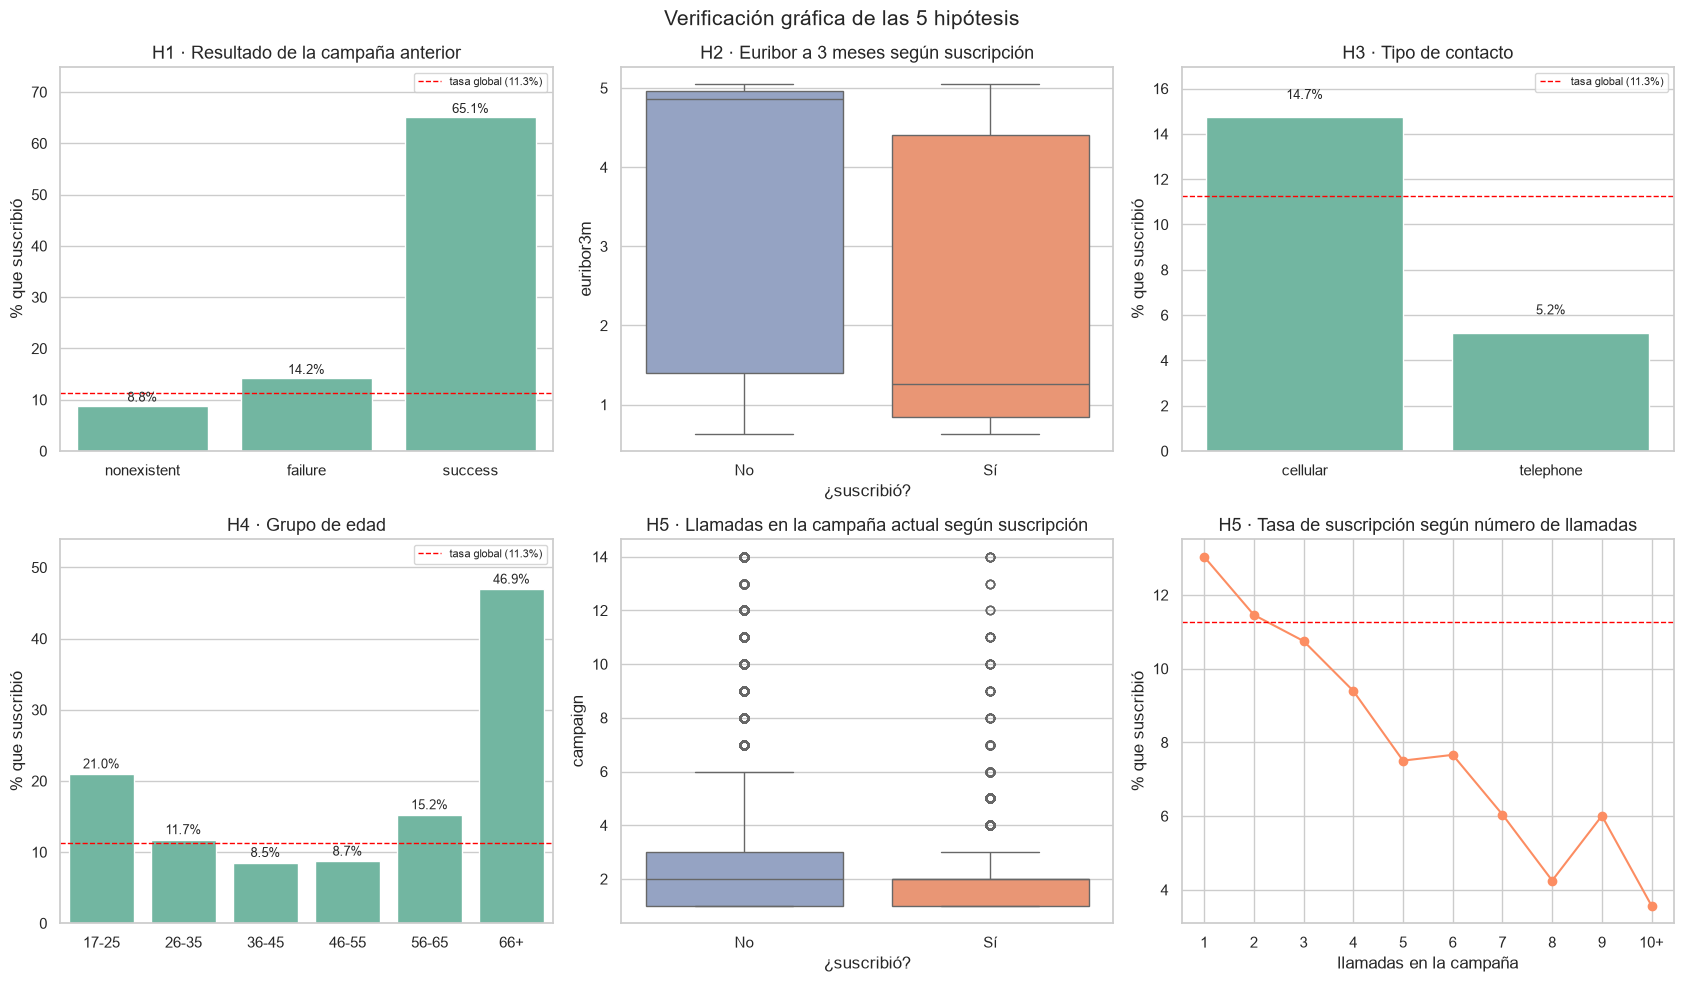

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
paleta = {0: "#8da0cb", 1: "#fc8d62"}

def barras_tasa(ax, col, titulo, orden=None):
    tasa = df.groupby(col)[OBJETIVO].mean().mul(100)
    if orden is not None:
        tasa = tasa.reindex(orden)
    sns.barplot(x=tasa.index.astype(str), y=tasa.values, ax=ax, color="#66c2a5")
    ax.axhline(tasa_global, color="red", ls="--", lw=1, label=f"tasa global ({tasa_global:.1f}%)")
    for i, v in enumerate(tasa.values):
        ax.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=9)
    ax.set_ylim(0, tasa.max() * 1.15)
    ax.set_title(titulo); ax.set_xlabel(""); ax.set_ylabel("% que suscribió"); ax.legend(fontsize=8)

barras_tasa(axes[0, 0], "poutcome", "H1 · Resultado de la campaña anterior", ["nonexistent", "failure", "success"])
sns.boxplot(x=df[OBJETIVO].map({0: "No", 1: "Sí"}), y=df["euribor3m"], ax=axes[0, 1], palette=["#8da0cb", "#fc8d62"])
axes[0, 1].set_title("H2 · Euribor a 3 meses según suscripción"); axes[0, 1].set_xlabel("¿suscribió?")
barras_tasa(axes[0, 2], "contact", "H3 · Tipo de contacto")
barras_tasa(axes[1, 0], "grupo_edad", "H4 · Grupo de edad")
sns.boxplot(x=df[OBJETIVO].map({0: "No", 1: "Sí"}), y=df["campaign"], ax=axes[1, 1], palette=["#8da0cb", "#fc8d62"])
axes[1, 1].set_title("H5 · Llamadas en la campaña actual según suscripción"); axes[1, 1].set_xlabel("¿suscribió?")
tasa_campaign = df.groupby(df["campaign"].clip(upper=10))[OBJETIVO].mean().mul(100)
axes[1, 2].plot(tasa_campaign.index, tasa_campaign.values, marker="o", color="#fc8d62")
axes[1, 2].axhline(tasa_global, color="red", ls="--", lw=1)
axes[1, 2].set_xticks(range(1, 11)); axes[1, 2].set_xticklabels([str(i) for i in range(1, 10)] + ["10+"])
axes[1, 2].set_title("H5 · Tasa de suscripción según número de llamadas")
axes[1, 2].set_xlabel("llamadas en la campaña"); axes[1, 2].set_ylabel("% que suscribió")
plt.suptitle("Verificación gráfica de las 5 hipótesis", fontsize=15)
plt.tight_layout()
guardar_figura("04_graficas_hipotesis")
plt.show()

### Interpretación de las hipótesis
- **H1 – Se confirma.** Si la campaña anterior fue exitosa, la tasa de suscripción sube a **65,1 %**, frente a 14,2 % (fracaso) y 8,8 % (sin campaña previa). Es la asociación más fuerte entre las categóricas (V = 0,32).
- **H2 – Se confirma.** La mediana del Euribor es **1,27 %** en quienes suscriben frente a **4,86 %** en quienes no. El tamaño del efecto es grande (r_rb ≈ 0,49): las tasas bajas de interés coinciden con las campañas exitosas.
- **H3 – Se confirma.** Por celular suscribe el **14,7 %** y por teléfono fijo solo el **5,2 %** (asociación moderada, V = 0,15).
- **H4 – Se confirma.** La relación con la edad tiene forma de **U**: los menores de 26 años (21,0 %) y, sobre todo, los mayores de 65 (46,9 %) suscriben mucho más que el grupo de 36 a 55 años (≈ 8,5 %).
- **H5 – Se confirma, con efecto pequeño.** Quienes suscriben recibieron menos llamadas (media 2,05 vs 2,56). La tasa cae de 13,0 % con 1 llamada a 3,6 % con 10 o más, pero el efecto es pequeño (r_rb ≈ 0,11).

## 6. Conclusiones del análisis multivariado
1. **Multicolinealidad:** `emp_var_rate`, `euribor3m` y `nr_employed` tienen correlaciones entre 0,91 y 0,97. Miden lo mismo (el ciclo económico), por lo que en un modelo conviene usar solo una de ellas o aplicar PCA (notebook 05).
2. **Variables más relacionadas con `y`:** `duration` (r = 0,41, pero con fuga de información), `nr_employed` (−0,36), `contactado_antes` (0,33) y `euribor3m` (−0,31). Las variables sociodemográficas numéricas (`age`) casi no tienen relación *lineal* con `y`.
3. **Entre las categóricas** la asociación más fuerte es con el historial (`contactado_antes` y `poutcome`, V ≈ 0,32), seguida del mes (0,28), la ocupación (0,15) y el tipo de contacto (0,15). `housing`, `loan` y `day_of_week` prácticamente no aportan (V < 0,03).
4. **Interacción mes × contacto:** marzo, septiembre, octubre y diciembre superan el 40 % de éxito por celular; en mayo y julio la tasa es muy baja con cualquier canal. En junio la diferencia entre celular (42,6 %) y fijo (4,7 %) es enorme.
5. **Interacción Euribor × historial:** con Euribor < 2 % y campaña anterior exitosa la tasa llega a **66,6 %**; con Euribor ≥ 4 % no supera el 8,6 % en ningún grupo. Solo 14 llamadas ocurrieron con Euribor entre 2 % y 4 %, así que esa fila no es representativa.
6. **Las 5 hipótesis se confirman** (p < 0,05). Por el tamaño de la muestra, la decisión se apoya en el tamaño del efecto: el contexto económico (H2) y el historial (H1) son los factores con mayor peso; la cantidad de llamadas (H5) tiene un efecto real pero pequeño.